# PCOS Symptom-Only Screening — Random Forest

This notebook builds a **screening model** (not a diagnostic tool) for PCOS risk using
**only self-reportable fields** — no blood tests, hormone panels, or ultrasound.

Data source: `PCOS_data_without_infertility.xlsx` (Kottarathil, Kaggle — 541 patients, 10 hospitals in Kerala, India).

**Important framing:** the PCOS label in this dataset was assigned by clinicians using full
Rotterdam criteria (including ultrasound/labs). This model learns to predict *that diagnosis*
from a reduced, self-reportable feature set — it approximates the diagnostic outcome, it does
not itself apply Rotterdam criteria. Always present results as "risk indication — consult a
doctor", never as a diagnosis.

In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
import joblib

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)


In [3]:
df_raw = pd.read_excel("../data/PCOS_data_without_infertility.xlsx", sheet_name="Full_new")
df_raw.columns = [c.strip() for c in df_raw.columns]  # strip stray whitespace in headers
print(df_raw.shape)
df_raw.head(3)


(541, 45)


,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),Hb(g/dl),Cycle(R/I),Cycle length(days),Marraige Status (Yrs),Pregnant(Y/N),No. of aborptions,I beta-HCG(mIU/mL),II beta-HCG(mIU/mL),FSH(mIU/mL),LH(mIU/mL),FSH/LH,Hip(inch),Waist(inch),Waist:Hip Ratio,TSH (mIU/L),AMH(ng/mL),PRL(ng/mL),Vit D3 (ng/mL),PRG(ng/mL),RBS(mg/dl),Weight gain(Y/N),hair growth(Y/N),Skin darkening (Y/N),Hair loss(Y/N),Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.6,152.0,19.300000,15,78,22,10.48,2,5,7.0,0,0,1.99,1.99,7.95,3.68,2.160326,36,30,0.833333,0.68,2.07,45.16,17.1,0.57,92.0,0,0,0,0,0,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,24.921163,15,74,20,11.70,2,5,11.0,1,0,60.80,1.99,6.73,1.09,6.174312,38,32,0.842105,3.16,1.53,20.09,61.3,0.97,92.0,0,0,0,0,0,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,25.270891,11,72,18,11.80,2,5,10.0,1,0,494.08,494.08,5.54,0.88,6.295455,40,36,0.900000,2.54,6.63,10.52,49.7,0.36,84.0,0,0,0,1,1,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN


## Feature selection

Keeping only fields a user can answer **without any test, machine, or scan**.
Everything clinical (hormones, ultrasound follicle counts, blood pressure, blood group, vitals) is dropped.

In [4]:
KEEP_RAW = {
    "PCOS (Y/N)": "pcos",
    "Age (yrs)": "age",
    "Weight (Kg)": "weight_kg",
    "Height(Cm)": "height_cm",
    "Cycle(R/I)": "cycle_code",          # 2 = regular, 4/5 = irregular (raw dataset coding)
    "Cycle length(days)": "cycle_length_days",
    "Weight gain(Y/N)": "weight_gain",
    "hair growth(Y/N)": "hair_growth",
    "Skin darkening (Y/N)": "skin_darkening",
    "Hair loss(Y/N)": "hair_loss",
    "Pimples(Y/N)": "acne",
    "Fast food (Y/N)": "fast_food",
    "Reg.Exercise(Y/N)": "regular_exercise",
    "Hip(inch)": "hip_inch",
    "Waist(inch)": "waist_inch",
}

df = df_raw[list(KEEP_RAW.keys())].rename(columns=KEEP_RAW).copy()
print("Selected", len(df.columns) - 1, "features (+ target)")
df.head(3)


Selected 14 features (+ target)


,pcos,age,weight_kg,height_cm,cycle_code,cycle_length_days,weight_gain,hair_growth,skin_darkening,hair_loss,acne,fast_food,regular_exercise,hip_inch,waist_inch
0,0,28,44.6,152.0,2,5,0,0,0,0,0,1.0,0,36,30
1,0,36,65.0,161.5,2,5,0,0,0,0,0,0.0,0,38,32
2,1,33,68.8,165.0,2,5,0,0,0,1,1,1.0,0,40,36


## Cleaning & feature engineering

- `cycle_code` (2/4/5) -> `cycle_irregular` (0/1)
- Derive `bmi` from weight & height instead of keeping raw weight/height
- Derive `waist_hip_ratio` (optional field, self-measurable with a tape)
- Impute the handful of missing values (median for numeric, mode for binary)

In [5]:
df["cycle_irregular"] = (df["cycle_code"] != 2).astype(int)
df = df.drop(columns=["cycle_code"])

df["bmi"] = df["weight_kg"] / ((df["height_cm"] / 100) ** 2)
df["waist_hip_ratio"] = df["waist_inch"] / df["hip_inch"]

print("Missing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])

for col in df.columns:
    if df[col].isna().any():
        if df[col].dropna().isin([0, 1]).all():
            df[col] = df[col].fillna(df[col].mode()[0])
        else:
            df[col] = df[col].fillna(df[col].median())

df["pcos"] = df["pcos"].astype(int)
print("\nFinal shape:", df.shape)
df.describe().T


Missing values per column:
fast_food    1
dtype: int64

Final shape: (541, 17)


,count,mean,std,min,25%,50%,75%,max
pcos,541.0,0.327172,0.469615,0.000000,0.000000,0.000000,1.000000,1.000000
age,541.0,31.430684,5.411006,20.000000,28.000000,31.000000,35.000000,48.000000
weight_kg,541.0,59.637153,11.028287,31.000000,52.000000,59.000000,65.000000,108.000000
height_cm,541.0,156.484835,6.033545,137.000000,152.000000,156.000000,160.000000,180.000000
cycle_length_days,541.0,4.940850,1.492020,0.000000,4.000000,5.000000,5.000000,12.000000
weight_gain,541.0,0.377079,0.485104,0.000000,0.000000,0.000000,1.000000,1.000000
hair_growth,541.0,0.273567,0.446202,0.000000,0.000000,0.000000,1.000000,1.000000
skin_darkening,541.0,0.306839,0.461609,0.000000,0.000000,0.000000,1.000000,1.000000
hair_loss,541.0,0.452865,0.498234,0.000000,0.000000,0.000000,1.000000,1.000000
acne,541.0,0.489834,0.500359,0.000000,0.000000,0.000000,1.000000,1.000000


## Exploratory look: class balance & symptom prevalence by PCOS status

pcos
0    364
1    177
Name: count, dtype: int64
pcos
0    0.673
1    0.327
Name: proportion, dtype: float64


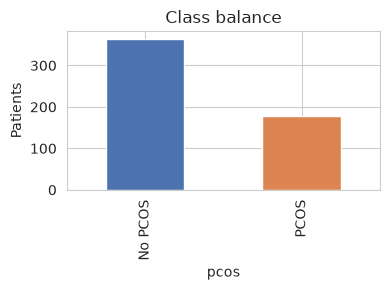

In [6]:
print(df["pcos"].value_counts())
print(df["pcos"].value_counts(normalize=True).round(3))

fig, ax = plt.subplots(figsize=(4, 3))
df["pcos"].value_counts().rename({0: "No PCOS", 1: "PCOS"}).plot(kind="bar", color=["#4C72B0", "#DD8452"], ax=ax)
ax.set_ylabel("Patients")
ax.set_title("Class balance")
plt.tight_layout()
plt.show()


                  No PCOS  PCOS
fast_food            38.5  78.5
acne                 39.0  69.5
weight_gain          22.8  68.4
skin_darkening       15.4  62.1
hair_loss            39.3  57.6
hair_growth          12.9  57.1
cycle_irregular      15.4  53.7
regular_exercise     22.8  28.8


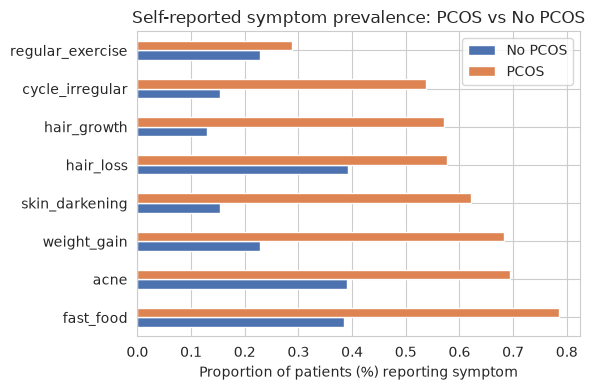

In [7]:
binary_symptoms = ["weight_gain", "hair_growth", "skin_darkening", "hair_loss",
                    "acne", "fast_food", "regular_exercise", "cycle_irregular"]

prevalence = df.groupby("pcos")[binary_symptoms].mean().T
prevalence.columns = ["No PCOS", "PCOS"]
prevalence = prevalence.sort_values("PCOS", ascending=False)
print((prevalence * 100).round(1))

prevalence.plot(kind="barh", figsize=(6, 4), color=["#4C72B0", "#DD8452"])
plt.xlabel("Proportion of patients (%) reporting symptom")
plt.title("Self-reported symptom prevalence: PCOS vs No PCOS")
plt.tight_layout()
plt.show()


## Train / test split

Stratified 80/20 split so the class ratio is preserved in both sets.

In [8]:
feature_cols = [c for c in df.columns if c != "pcos"]
X = df[feature_cols]
y = df["pcos"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (432, 16)  Test: (109, 16)


## Model: Random Forest

Using `class_weight="balanced"` to handle the ~2:1 class imbalance (no PCOS : PCOS) without
needing an external oversampling library. `max_depth` is kept shallow since we only have 541
rows total — an unconstrained forest would overfit easily.

In [19]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_recall = cross_val_score(rf, X_train, y_train, cv=cv, scoring="recall")
cv_roc_auc = cross_val_score(rf, X_train, y_train, cv=cv, scoring="roc_auc")

print(f"5-fold CV recall (PCOS class): {cv_recall.mean():.3f} +/- {cv_recall.std():.3f}")
print(f"5-fold CV ROC-AUC:            {cv_roc_auc.mean():.3f} +/- {cv_roc_auc.std():.3f}")

rf.fit(X_train, y_train)


5-fold CV recall (PCOS class): 0.801 +/- 0.048
5-fold CV ROC-AUC:            0.883 +/- 0.012


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_featu

## Evaluation on held-out test set

              precision    recall  f1-score   support

     No PCOS       0.89      0.90      0.90        73
        PCOS       0.80      0.78      0.79        36

    accuracy                           0.86       109
   macro avg       0.85      0.84      0.84       109
weighted avg       0.86      0.86      0.86       109

ROC-AUC: 0.882


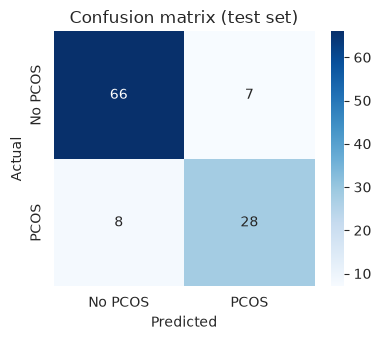

In [18]:
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["No PCOS", "PCOS"]))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 3))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4, 3.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No PCOS", "PCOS"], yticklabels=["No PCOS", "PCOS"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion matrix (test set)")
plt.tight_layout()
plt.show()


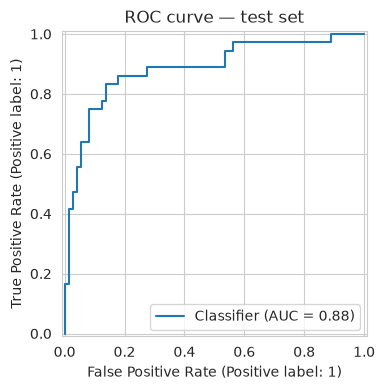

In [11]:
fig, ax = plt.subplots(figsize=(4.5, 4))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax)
ax.set_title("ROC curve — test set")
plt.tight_layout()
plt.show()


## Feature importance

Which self-reported symptoms actually drive the model's predictions — useful both for
sanity-checking the model and for explaining a result to a user later.

skin_darkening       0.150
hair_growth          0.146
weight_gain          0.126
cycle_length_days    0.078
fast_food            0.063
cycle_irregular      0.062
age                  0.055
waist_hip_ratio      0.053
bmi                  0.049
weight_kg            0.043
waist_inch           0.040
hip_inch             0.039
height_cm            0.037
acne                 0.030
regular_exercise     0.017
hair_loss            0.012
dtype: float64


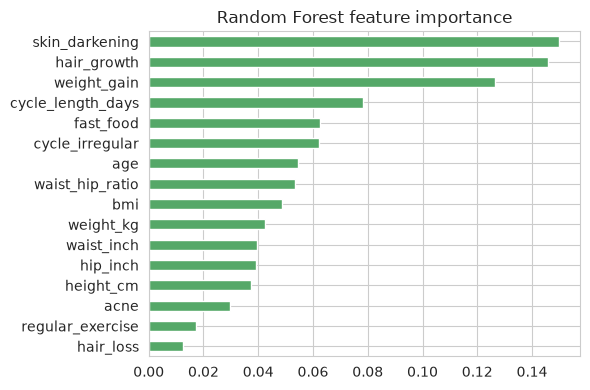

In [12]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances.round(3))

fig, ax = plt.subplots(figsize=(6, 4))
importances.sort_values().plot(kind="barh", color="#55A868", ax=ax)
ax.set_title("Random Forest feature importance")
plt.tight_layout()
plt.show()


## Save model artifacts

These are what the Phase 2 voice/text agent will load to score a new user's answers.

In [13]:
joblib.dump(rf, "../pcos_rf_model.pkl")

with open("../pcos_model_features.json", "w") as f:
    json.dump(feature_cols, f, indent=2)

print("Saved: pcos_rf_model.pkl, pcos_model_features.json")
print("\nFeature order the model expects:")
for c in feature_cols:
    print(" -", c)


Saved: pcos_rf_model.pkl, pcos_model_features.json

Feature order the model expects:
 - age
 - weight_kg
 - height_cm
 - cycle_length_days
 - weight_gain
 - hair_growth
 - skin_darkening
 - hair_loss
 - acne
 - fast_food
 - regular_exercise
 - hip_inch
 - waist_inch
 - cycle_irregular
 - bmi
 - waist_hip_ratio
